<a href="https://colab.research.google.com/github/RenzoEspinozaTuesta/Miner-a-de-Datos/blob/main/BDA_LAB11_Bases_de_datos_NoSQL_embebidas_con_datos_burs%C3%A1tiles_y_procesamiento_en_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Semana 11 - Laboratorio 11 (PMD) - NoSQL + Python + BigData + TinyDB.
Bases de datos NoSQL embebidas con datos bursátiles y procesamiento en Python


Elaborado por: Renzo Espinoza Tuesta

# Laboratorio 11 - NoSQL + Python + Big Data + TinyDB

**Tema:** Bases de datos NoSQL embebidas con datos bursátiles y procesamiento en Python.

**Ejercicios desarrollados:** A) ampliación a 8 tickers con BVN, BAP y FSM. B) consulta avanzada TinyDB para top 5 caídas intradía.

# Laboratorio 11 - NoSQL + Python + Big Data + TinyDB

**Tema:** Bases de datos NoSQL embebidas con datos bursátiles y procesamiento en Python.

**Ejercicios desarrollados:** A) ampliación a 8 tickers con BVN, BAP y FSM. B) consulta avanzada TinyDB para top 5 caídas intradía.

# Laboratorio 11 - NoSQL + Python + Big Data + TinyDB

**Tema:** Bases de datos NoSQL embebidas con datos bursátiles y procesamiento en Python.

**Ejercicios desarrollados:** A) ampliación a 8 tickers con BVN, BAP y FSM. B) consulta avanzada TinyDB para top 5 caídas intradía.

In [ ]:
# Instalación esperada en Colab
# !pip install tinydb yfinance networkx matplotlib pandas numpy -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tinydb import TinyDB, Query
import shelve, os, json
from pathlib import Path
print('Librerías importadas correctamente')

Librerías importadas correctamente


## 1. Universo de tickers y datos de trabajo

Se amplió el universo original de 5 acciones tecnológicas a 8 tickers: `AAPL`, `MSFT`, `GOOGL`, `AMZN`, `NVDA`, `BVN`, `BAP` y `FSM`. En Colab, la descarga puede ejecutarse con `yfinance`; en este notebook se incluye una muestra histórica autocontenida para garantizar reproducibilidad de los gráficos y bases NoSQL.

In [ ]:
tickers = ['AAPL','MSFT','GOOGL','AMZN','NVDA','BVN','BAP','FSM']
print(tickers)

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'BVN', 'BAP', 'FSM']


In [ ]:
records = [{'fecha': '2026-04-29', 'ticker': 'AAPL', 'apertura': 267.55, 'maximo': 271.04, 'minimo': 267.04, 'cierre': 270.17, 'volumen': 30047869}, {'fecha': '2026-04-30', 'ticker': 'AAPL', 'apertura': 270.5, 'maximo': 276.0, 'minimo': 268.14, 'cierre': 271.35, 'volumen': 91848230}, {'fecha': '2026-05-06', 'ticker': 'AAPL', 'apertura': 281.92, 'maximo': 288.03, 'minimo': 281.07, 'cierre': 287.51, 'volumen': 58336072}, {'fecha': '2026-05-07', 'ticker': 'AAPL', 'apertura': 289.27, 'maximo': 292.13, 'minimo': 285.78, 'cierre': 287.44, 'volumen': 45224300}, {'fecha': '2026-05-08', 'ticker': 'AAPL', 'apertura': 290.01, 'maximo': 294.76, 'minimo': 290.0, 'cierre': 293.32, 'volumen': 52692761}, {'fecha': '2026-05-11', 'ticker': 'AAPL', 'apertura': 291.98, 'maximo': 293.88, 'minimo': 290.23, 'cierre': 292.68, 'volumen': 42247285}, {'fecha': '2026-05-12', 'ticker': 'AAPL', 'apertura': 292.56, 'maximo': 295.27, 'minimo': 292.56, 'cierre': 294.8, 'volumen': 45748129}, {'fecha': '2026-05-13', 'ticker': 'AAPL', 'apertura': 293.5, 'maximo': 300.92, 'minimo': 293.5, 'cierre': 298.87, 'volumen': 52684260}, {'fecha': '2026-05-14', 'ticker': 'AAPL', 'apertura': 299.82, 'maximo': 300.45, 'minimo': 295.38, 'cierre': 298.21, 'volumen': 35324922}, {'fecha': '2026-05-15', 'ticker': 'AAPL', 'apertura': 297.9, 'maximo': 303.2, 'minimo': 296.52, 'cierre': 300.23, 'volumen': 54622773}, {'fecha': '2026-05-18', 'ticker': 'AAPL', 'apertura': 300.24, 'maximo': 300.66, 'minimo': 294.91, 'cierre': 297.84, 'volumen': 34349993}, {'fecha': '2026-05-19', 'ticker': 'AAPL', 'apertura': 296.97, 'maximo': 300.51, 'minimo': 296.35, 'cierre': 298.97, 'volumen': 39867367}, {'fecha': '2026-05-20', 'ticker': 'AAPL', 'apertura': 298.18, 'maximo': 302.8, 'minimo': 298.08, 'cierre': 302.25, 'volumen': 37281629}, {'fecha': '2026-05-21', 'ticker': 'AAPL', 'apertura': 301.06, 'maximo': 305.54, 'minimo': 300.4, 'cierre': 304.99, 'volumen': 42826465}, {'fecha': '2026-05-22', 'ticker': 'AAPL', 'apertura': 306.12, 'maximo': 311.4, 'minimo': 305.84, 'cierre': 308.82, 'volumen': 43481409}, {'fecha': '2026-05-26', 'ticker': 'AAPL', 'apertura': 309.56, 'maximo': 311.82, 'minimo': 307.67, 'cierre': 308.33, 'volumen': 46523440}, {'fecha': '2026-05-27', 'ticker': 'AAPL', 'apertura': 308.33, 'maximo': 313.26, 'minimo': 308.3, 'cierre': 310.85, 'volumen': 50193702}, {'fecha': '2026-05-28', 'ticker': 'AAPL', 'apertura': 310.68, 'maximo': 312.8, 'minimo': 309.57, 'cierre': 312.51, 'volumen': 47256727}, {'fecha': '2026-05-29', 'ticker': 'AAPL', 'apertura': 311.78, 'maximo': 315.0, 'minimo': 309.53, 'cierre': 312.06, 'volumen': 69192740}, {'fecha': '2026-04-29', 'ticker': 'AMZN', 'apertura': 257.99, 'maximo': 265.91, 'minimo': 257.7, 'cierre': 263.04, 'volumen': 72367910}, {'fecha': '2026-04-30', 'ticker': 'AMZN', 'apertura': 273.17, 'maximo': 273.88, 'minimo': 256.16, 'cierre': 265.06, 'volumen': 100974867}, {'fecha': '2026-05-06', 'ticker': 'AMZN', 'apertura': 272.89, 'maximo': 277.8, 'minimo': 272.21, 'cierre': 274.99, 'volumen': 44551955}, {'fecha': '2026-05-07', 'ticker': 'AMZN', 'apertura': 275.02, 'maximo': 276.63, 'minimo': 270.49, 'cierre': 271.17, 'volumen': 35892879}, {'fecha': '2026-05-08', 'ticker': 'AMZN', 'apertura': 271.63, 'maximo': 274.0, 'minimo': 269.95, 'cierre': 272.68, 'volumen': 34732681}, {'fecha': '2026-05-11', 'ticker': 'AMZN', 'apertura': 269.84, 'maximo': 273.63, 'minimo': 268.48, 'cierre': 268.99, 'volumen': 38176696}, {'fecha': '2026-05-12', 'ticker': 'AMZN', 'apertura': 266.71, 'maximo': 267.65, 'minimo': 262.63, 'cierre': 265.82, 'volumen': 36776221}, {'fecha': '2026-05-13', 'ticker': 'AMZN', 'apertura': 264.43, 'maximo': 270.72, 'minimo': 263.2, 'cierre': 270.13, 'volumen': 39670915}, {'fecha': '2026-05-14', 'ticker': 'AMZN', 'apertura': 269.15, 'maximo': 270.78, 'minimo': 266.63, 'cierre': 267.22, 'volumen': 31338435}, {'fecha': '2026-05-15', 'ticker': 'AMZN', 'apertura': 262.5, 'maximo': 264.36, 'minimo': 260.89, 'cierre': 264.14, 'volumen': 40770344}, {'fecha': '2026-05-18', 'ticker': 'AMZN', 'apertura': 263.87, 'maximo': 268.85, 'minimo': 262.53, 'cierre': 264.86, 'volumen': 33538205}, {'fecha': '2026-05-19', 'ticker': 'AMZN', 'apertura': 262.04, 'maximo': 262.25, 'minimo': 255.19, 'cierre': 259.34, 'volumen': 40114273}, {'fecha': '2026-05-20', 'ticker': 'AMZN', 'apertura': 260.05, 'maximo': 265.58, 'minimo': 259.53, 'cierre': 265.01, 'volumen': 34433668}, {'fecha': '2026-05-21', 'ticker': 'AMZN', 'apertura': 263.5, 'maximo': 269.49, 'minimo': 261.37, 'cierre': 268.46, 'volumen': 36391475}, {'fecha': '2026-05-22', 'ticker': 'AMZN', 'apertura': 268.66, 'maximo': 269.79, 'minimo': 266.24, 'cierre': 266.32, 'volumen': 27387154}, {'fecha': '2026-05-26', 'ticker': 'AMZN', 'apertura': 267.94, 'maximo': 269.3, 'minimo': 262.07, 'cierre': 265.29, 'volumen': 37865557}, {'fecha': '2026-05-27', 'ticker': 'AMZN', 'apertura': 266.15, 'maximo': 272.41, 'minimo': 265.7, 'cierre': 271.85, 'volumen': 39659307}, {'fecha': '2026-05-28', 'ticker': 'AMZN', 'apertura': 272.27, 'maximo': 274.5, 'minimo': 267.44, 'cierre': 274.0, 'volumen': 40293784}, {'fecha': '2026-05-29', 'ticker': 'AMZN', 'apertura': 271.29, 'maximo': 274.75, 'minimo': 269.64, 'cierre': 270.64, 'volumen': 53847382}, {'fecha': '2026-04-29', 'ticker': 'BAP', 'apertura': 321.07, 'maximo': 325.16, 'minimo': 315.25, 'cierre': 318.06, 'volumen': 192689}, {'fecha': '2026-04-30', 'ticker': 'BAP', 'apertura': 320.76, 'maximo': 325.87, 'minimo': 317.22, 'cierre': 324.17, 'volumen': 188728}, {'fecha': '2026-05-06', 'ticker': 'BAP', 'apertura': 325.0, 'maximo': 328.46, 'minimo': 317.94, 'cierre': 326.55, 'volumen': 303947}, {'fecha': '2026-05-07', 'ticker': 'BAP', 'apertura': 325.2, 'maximo': 328.99, 'minimo': 319.17, 'cierre': 321.77, 'volumen': 285289}, {'fecha': '2026-05-08', 'ticker': 'BAP', 'apertura': 326.6, 'maximo': 332.8, 'minimo': 323.75, 'cierre': 330.5, 'volumen': 452534}, {'fecha': '2026-05-11', 'ticker': 'BAP', 'apertura': 330.59, 'maximo': 333.13, 'minimo': 321.53, 'cierre': 322.42, 'volumen': 318328}, {'fecha': '2026-05-12', 'ticker': 'BAP', 'apertura': 319.5, 'maximo': 326.15, 'minimo': 317.58, 'cierre': 323.82, 'volumen': 302610}, {'fecha': '2026-05-13', 'ticker': 'BAP', 'apertura': 323.33, 'maximo': 324.74, 'minimo': 312.0, 'cierre': 317.68, 'volumen': 503148}, {'fecha': '2026-05-14', 'ticker': 'BAP', 'apertura': 317.89, 'maximo': 329.02, 'minimo': 316.0, 'cierre': 327.69, 'volumen': 576458}, {'fecha': '2026-05-15', 'ticker': 'BAP', 'apertura': 321.9, 'maximo': 338.86, 'minimo': 313.75, 'cierre': 316.31, 'volumen': 667964}, {'fecha': '2026-05-18', 'ticker': 'BAP', 'apertura': 302.09, 'maximo': 310.28, 'minimo': 300.0, 'cierre': 303.86, 'volumen': 337750}, {'fecha': '2026-05-19', 'ticker': 'BAP', 'apertura': 306.43, 'maximo': 316.57, 'minimo': 303.87, 'cierre': 315.79, 'volumen': 648774}, {'fecha': '2026-05-20', 'ticker': 'BAP', 'apertura': 313.37, 'maximo': 335.55, 'minimo': 313.37, 'cierre': 333.27, 'volumen': 668888}, {'fecha': '2026-05-21', 'ticker': 'BAP', 'apertura': 331.42, 'maximo': 345.77, 'minimo': 328.91, 'cierre': 344.0, 'volumen': 528324}, {'fecha': '2026-05-22', 'ticker': 'BAP', 'apertura': 344.48, 'maximo': 350.0, 'minimo': 332.55, 'cierre': 334.3, 'volumen': 436327}, {'fecha': '2026-05-26', 'ticker': 'BAP', 'apertura': 337.3, 'maximo': 353.61, 'minimo': 336.11, 'cierre': 351.75, 'volumen': 301234}, {'fecha': '2026-05-27', 'ticker': 'BAP', 'apertura': 351.24, 'maximo': 354.41, 'minimo': 343.08, 'cierre': 348.24, 'volumen': 340768}, {'fecha': '2026-05-28', 'ticker': 'BAP', 'apertura': 345.77, 'maximo': 345.77, 'minimo': 336.82, 'cierre': 341.5, 'volumen': 681941}, {'fecha': '2026-05-29', 'ticker': 'BAP', 'apertura': 340.79, 'maximo': 347.64, 'minimo': 337.67, 'cierre': 342.63, 'volumen': 739634}, {'fecha': '2026-04-29', 'ticker': 'BVN', 'apertura': 30.66, 'maximo': 30.72, 'minimo': 29.88, 'cierre': 30.02, 'volumen': 1783246}, {'fecha': '2026-04-30', 'ticker': 'BVN', 'apertura': 31.19, 'maximo': 32.73, 'minimo': 30.38, 'cierre': 32.59, 'volumen': 3234370}, {'fecha': '2026-05-06', 'ticker': 'BVN', 'apertura': 33.29, 'maximo': 34.43, 'minimo': 33.11, 'cierre': 34.05, 'volumen': 1126022}, {'fecha': '2026-05-07', 'ticker': 'BVN', 'apertura': 34.8, 'maximo': 35.77, 'minimo': 33.87, 'cierre': 33.93, 'volumen': 2079583}, {'fecha': '2026-05-08', 'ticker': 'BVN', 'apertura': 34.61, 'maximo': 35.74, 'minimo': 34.26, 'cierre': 35.36, 'volumen': 774537}, {'fecha': '2026-05-11', 'ticker': 'BVN', 'apertura': 35.86, 'maximo': 37.86, 'minimo': 35.85, 'cierre': 37.75, 'volumen': 1174383}, {'fecha': '2026-05-12', 'ticker': 'BVN', 'apertura': 36.86, 'maximo': 38.19, 'minimo': 36.39, 'cierre': 38.09, 'volumen': 1584096}, {'fecha': '2026-05-13', 'ticker': 'BVN', 'apertura': 37.78, 'maximo': 38.65, 'minimo': 37.46, 'cierre': 38.47, 'volumen': 786586}, {'fecha': '2026-05-14', 'ticker': 'BVN', 'apertura': 38.09, 'maximo': 38.5, 'minimo': 36.86, 'cierre': 37.15, 'volumen': 1418312}, {'fecha': '2026-05-15', 'ticker': 'BVN', 'apertura': 35.6, 'maximo': 35.63, 'minimo': 34.0, 'cierre': 34.29, 'volumen': 2135468}, {'fecha': '2026-05-18', 'ticker': 'BVN', 'apertura': 34.5, 'maximo': 34.88, 'minimo': 33.9, 'cierre': 34.01, 'volumen': 661095}, {'fecha': '2026-05-19', 'ticker': 'BVN', 'apertura': 33.29, 'maximo': 33.43, 'minimo': 32.12, 'cierre': 32.87, 'volumen': 1007416}, {'fecha': '2026-05-20', 'ticker': 'BVN', 'apertura': 33.33, 'maximo': 34.09, 'minimo': 32.71, 'cierre': 33.89, 'volumen': 987200}, {'fecha': '2026-05-21', 'ticker': 'BVN', 'apertura': 33.5, 'maximo': 34.59, 'minimo': 33.12, 'cierre': 33.71, 'volumen': 674001}, {'fecha': '2026-05-22', 'ticker': 'BVN', 'apertura': 33.74, 'maximo': 34.3, 'minimo': 32.95, 'cierre': 33.46, 'volumen': 822572}, {'fecha': '2026-05-26', 'ticker': 'BVN', 'apertura': 34.39, 'maximo': 35.33, 'minimo': 33.91, 'cierre': 35.09, 'volumen': 768193}, {'fecha': '2026-05-27', 'ticker': 'BVN', 'apertura': 34.24, 'maximo': 34.97, 'minimo': 34.01, 'cierre': 34.63, 'volumen': 532826}, {'fecha': '2026-05-28', 'ticker': 'BVN', 'apertura': 34.21, 'maximo': 35.6, 'minimo': 33.79, 'cierre': 35.01, 'volumen': 596780}, {'fecha': '2026-05-29', 'ticker': 'BVN', 'apertura': 35.03, 'maximo': 37.19, 'minimo': 34.9, 'cierre': 36.89, 'volumen': 2264190}, {'fecha': '2026-04-29', 'ticker': 'FSM', 'apertura': 9.45, 'maximo': 9.5, 'minimo': 9.23, 'cierre': 9.33, 'volumen': 4962892}, {'fecha': '2026-04-30', 'ticker': 'FSM', 'apertura': 9.74, 'maximo': 9.82, 'minimo': 9.43, 'cierre': 9.65, 'volumen': 4510675}, {'fecha': '2026-05-06', 'ticker': 'FSM', 'apertura': 9.66, 'maximo': 10.01, 'minimo': 9.66, 'cierre': 9.84, 'volumen': 5327024}, {'fecha': '2026-05-07', 'ticker': 'FSM', 'apertura': 10.32, 'maximo': 11.19, 'minimo': 10.23, 'cierre': 10.46, 'volumen': 13075277}, {'fecha': '2026-05-08', 'ticker': 'FSM', 'apertura': 10.65, 'maximo': 10.97, 'minimo': 10.46, 'cierre': 10.76, 'volumen': 5995232}, {'fecha': '2026-05-11', 'ticker': 'FSM', 'apertura': 10.85, 'maximo': 11.23, 'minimo': 10.71, 'cierre': 10.88, 'volumen': 8926730}, {'fecha': '2026-05-12', 'ticker': 'FSM', 'apertura': 10.73, 'maximo': 10.87, 'minimo': 10.1, 'cierre': 10.82, 'volumen': 5613888}, {'fecha': '2026-05-13', 'ticker': 'FSM', 'apertura': 10.67, 'maximo': 10.77, 'minimo': 10.38, 'cierre': 10.69, 'volumen': 4305817}, {'fecha': '2026-05-14', 'ticker': 'FSM', 'apertura': 10.62, 'maximo': 10.65, 'minimo': 10.21, 'cierre': 10.33, 'volumen': 5201003}, {'fecha': '2026-05-15', 'ticker': 'FSM', 'apertura': 9.8, 'maximo': 9.86, 'minimo': 9.41, 'cierre': 9.55, 'volumen': 12636038}, {'fecha': '2026-05-18', 'ticker': 'FSM', 'apertura': 9.74, 'maximo': 9.95, 'minimo': 9.44, 'cierre': 9.49, 'volumen': 4696802}, {'fecha': '2026-05-19', 'ticker': 'FSM', 'apertura': 9.31, 'maximo': 9.31, 'minimo': 9.07, 'cierre': 9.13, 'volumen': 5097505}, {'fecha': '2026-05-20', 'ticker': 'FSM', 'apertura': 9.31, 'maximo': 9.44, 'minimo': 9.13, 'cierre': 9.43, 'volumen': 3824561}, {'fecha': '2026-05-21', 'ticker': 'FSM', 'apertura': 9.18, 'maximo': 9.63, 'minimo': 9.15, 'cierre': 9.42, 'volumen': 3436627}, {'fecha': '2026-05-22', 'ticker': 'FSM', 'apertura': 9.36, 'maximo': 9.46, 'minimo': 9.23, 'cierre': 9.35, 'volumen': 2891743}, {'fecha': '2026-05-26', 'ticker': 'FSM', 'apertura': 9.6, 'maximo': 9.82, 'minimo': 9.52, 'cierre': 9.78, 'volumen': 3796708}, {'fecha': '2026-05-27', 'ticker': 'FSM', 'apertura': 9.5, 'maximo': 9.72, 'minimo': 9.46, 'cierre': 9.52, 'volumen': 3606315}, {'fecha': '2026-05-28', 'ticker': 'FSM', 'apertura': 9.4, 'maximo': 9.99, 'minimo': 9.3, 'cierre': 9.81, 'volumen': 6055981}, {'fecha': '2026-05-29', 'ticker': 'FSM', 'apertura': 9.76, 'maximo': 10.15, 'minimo': 9.75, 'cierre': 10.06, 'volumen': 5512813}, {'fecha': '2026-04-29', 'ticker': 'GOOGL', 'apertura': 347.57, 'maximo': 355.79, 'minimo': 344.21, 'cierre': 349.94, 'volumen': 35376328}, {'fecha': '2026-04-30', 'ticker': 'GOOGL', 'apertura': 374.07, 'maximo': 385.84, 'minimo': 365.82, 'cierre': 384.8, 'volumen': 72039993}, {'fecha': '2026-05-06', 'ticker': 'GOOGL', 'apertura': 394.25, 'maximo': 399.85, 'minimo': 392.76, 'cierre': 398.04, 'volumen': 31308476}, {'fecha': '2026-05-07', 'ticker': 'GOOGL', 'apertura': 399.92, 'maximo': 400.1, 'minimo': 392.68, 'cierre': 397.99, 'volumen': 24433490}, {'fecha': '2026-05-08', 'ticker': 'GOOGL', 'apertura': 397.0, 'maximo': 402.0, 'minimo': 396.36, 'cierre': 400.8, 'volumen': 21461849}, {'fecha': '2026-05-11', 'ticker': 'GOOGL', 'apertura': 393.65, 'maximo': 397.44, 'minimo': 388.47, 'cierre': 388.64, 'volumen': 30753738}, {'fecha': '2026-05-12', 'ticker': 'GOOGL', 'apertura': 387.34, 'maximo': 388.52, 'minimo': 382.77, 'cierre': 387.35, 'volumen': 26017488}, {'fecha': '2026-05-13', 'ticker': 'GOOGL', 'apertura': 385.6, 'maximo': 403.7, 'minimo': 385.0, 'cierre': 402.62, 'volumen': 28144555}, {'fecha': '2026-05-14', 'ticker': 'GOOGL', 'apertura': 397.28, 'maximo': 402.93, 'minimo': 395.84, 'cierre': 401.07, 'volumen': 21136716}, {'fecha': '2026-05-15', 'ticker': 'GOOGL', 'apertura': 396.32, 'maximo': 399.54, 'minimo': 393.18, 'cierre': 396.78, 'volumen': 20309702}, {'fecha': '2026-05-18', 'ticker': 'GOOGL', 'apertura': 395.69, 'maximo': 408.61, 'minimo': 394.53, 'cierre': 396.94, 'volumen': 26256067}, {'fecha': '2026-05-19', 'ticker': 'GOOGL', 'apertura': 396.96, 'maximo': 397.15, 'minimo': 386.11, 'cierre': 387.66, 'volumen': 37998227}, {'fecha': '2026-05-20', 'ticker': 'GOOGL', 'apertura': 387.7, 'maximo': 393.86, 'minimo': 382.9, 'cierre': 388.91, 'volumen': 30412350}, {'fecha': '2026-05-21', 'ticker': 'GOOGL', 'apertura': 385.7, 'maximo': 392.5, 'minimo': 383.02, 'cierre': 387.66, 'volumen': 23430632}, {'fecha': '2026-05-22', 'ticker': 'GOOGL', 'apertura': 387.35, 'maximo': 388.74, 'minimo': 381.77, 'cierre': 382.97, 'volumen': 19139743}, {'fecha': '2026-05-26', 'ticker': 'GOOGL', 'apertura': 384.51, 'maximo': 389.26, 'minimo': 382.6, 'cierre': 388.88, 'volumen': 26301286}, {'fecha': '2026-05-27', 'ticker': 'GOOGL', 'apertura': 386.67, 'maximo': 393.88, 'minimo': 385.9, 'cierre': 388.83, 'volumen': 22270452}, {'fecha': '2026-05-28', 'ticker': 'GOOGL', 'apertura': 388.0, 'maximo': 391.87, 'minimo': 385.16, 'cierre': 390.13, 'volumen': 22431188}, {'fecha': '2026-05-29', 'ticker': 'GOOGL', 'apertura': 385.24, 'maximo': 385.24, 'minimo': 378.46, 'cierre': 380.34, 'volumen': 43390282}, {'fecha': '2026-04-29', 'ticker': 'MSFT', 'apertura': 424.58, 'maximo': 426.82, 'minimo': 420.29, 'cierre': 424.46, 'volumen': 38288316}, {'fecha': '2026-04-30', 'ticker': 'MSFT', 'apertura': 410.81, 'maximo': 414.42, 'minimo': 398.01, 'cierre': 407.78, 'volumen': 70909408}, {'fecha': '2026-05-06', 'ticker': 'MSFT', 'apertura': 408.0, 'maximo': 418.42, 'minimo': 405.11, 'cierre': 413.96, 'volumen': 30285898}, {'fecha': '2026-05-07', 'ticker': 'MSFT', 'apertura': 420.11, 'maximo': 427.98, 'minimo': 418.76, 'cierre': 420.77, 'volumen': 34942445}, {'fecha': '2026-05-08', 'ticker': 'MSFT', 'apertura': 417.39, 'maximo': 418.63, 'minimo': 414.0, 'cierre': 415.12, 'volumen': 33383790}, {'fecha': '2026-05-11', 'ticker': 'MSFT', 'apertura': 407.87, 'maximo': 412.69, 'minimo': 405.5, 'cierre': 412.66, 'volumen': 35657943}, {'fecha': '2026-05-12', 'ticker': 'MSFT', 'apertura': 414.48, 'maximo': 415.5, 'minimo': 406.64, 'cierre': 407.77, 'volumen': 38594221}, {'fecha': '2026-05-13', 'ticker': 'MSFT', 'apertura': 403.2, 'maximo': 406.31, 'minimo': 401.03, 'cierre': 405.21, 'volumen': 29667073}, {'fecha': '2026-05-14', 'ticker': 'MSFT', 'apertura': 404.48, 'maximo': 411.84, 'minimo': 400.88, 'cierre': 409.43, 'volumen': 27077542}, {'fecha': '2026-05-15', 'ticker': 'MSFT', 'apertura': 414.27, 'maximo': 428.17, 'minimo': 412.91, 'cierre': 421.92, 'volumen': 50771160}, {'fecha': '2026-05-18', 'ticker': 'MSFT', 'apertura': 416.62, 'maximo': 425.12, 'minimo': 415.61, 'cierre': 423.54, 'volumen': 32564130}, {'fecha': '2026-05-19', 'ticker': 'MSFT', 'apertura': 429.9, 'maximo': 432.7, 'minimo': 416.49, 'cierre': 417.42, 'volumen': 33018678}, {'fecha': '2026-05-20', 'ticker': 'MSFT', 'apertura': 414.17, 'maximo': 422.1, 'minimo': 411.3, 'cierre': 421.06, 'volumen': 27864016}, {'fecha': '2026-05-21', 'ticker': 'MSFT', 'apertura': 424.75, 'maximo': 426.34, 'minimo': 415.71, 'cierre': 419.09, 'volumen': 30928381}, {'fecha': '2026-05-22', 'ticker': 'MSFT', 'apertura': 419.54, 'maximo': 424.4, 'minimo': 416.33, 'cierre': 418.57, 'volumen': 21950314}, {'fecha': '2026-05-26', 'ticker': 'MSFT', 'apertura': 416.43, 'maximo': 419.77, 'minimo': 413.02, 'cierre': 416.03, 'volumen': 29485401}, {'fecha': '2026-05-27', 'ticker': 'MSFT', 'apertura': 411.01, 'maximo': 415.94, 'minimo': 409.58, 'cierre': 412.67, 'volumen': 26991932}, {'fecha': '2026-05-28', 'ticker': 'MSFT', 'apertura': 412.98, 'maximo': 429.49, 'minimo': 412.67, 'cierre': 426.99, 'volumen': 45372450}, {'fecha': '2026-05-29', 'ticker': 'MSFT', 'apertura': 432.55, 'maximo': 450.33, 'minimo': 432.36, 'cierre': 450.24, 'volumen': 77293590}, {'fecha': '2026-04-29', 'ticker': 'NVDA', 'apertura': 212.7, 'maximo': 212.72, 'minimo': 207.58, 'cierre': 209.25, 'volumen': 123711821}, {'fecha': '2026-04-30', 'ticker': 'NVDA', 'apertura': 209.93, 'maximo': 210.3, 'minimo': 198.7, 'cierre': 199.57, 'volumen': 225239156}, {'fecha': '2026-05-06', 'ticker': 'NVDA', 'apertura': 199.89, 'maximo': 208.27, 'minimo': 198.61, 'cierre': 207.83, 'volumen': 188362812}, {'fecha': '2026-05-07', 'ticker': 'NVDA', 'apertura': 208.34, 'maximo': 214.2, 'minimo': 206.5, 'cierre': 211.5, 'volumen': 168307873}, {'fecha': '2026-05-08', 'ticker': 'NVDA', 'apertura': 213.03, 'maximo': 217.8, 'minimo': 212.89, 'cierre': 215.2, 'volumen': 136421361}, {'fecha': '2026-05-11', 'ticker': 'NVDA', 'apertura': 214.04, 'maximo': 222.3, 'minimo': 213.89, 'cierre': 219.44, 'volumen': 160685774}, {'fecha': '2026-05-12', 'ticker': 'NVDA', 'apertura': 218.55, 'maximo': 223.75, 'minimo': 214.92, 'cierre': 220.78, 'volumen': 159176619}, {'fecha': '2026-05-13', 'ticker': 'NVDA', 'apertura': 224.93, 'maximo': 227.84, 'minimo': 221.57, 'cierre': 225.83, 'volumen': 150405386}, {'fecha': '2026-05-14', 'ticker': 'NVDA', 'apertura': 229.85, 'maximo': 236.54, 'minimo': 229.3, 'cierre': 235.74, 'volumen': 180782857}, {'fecha': '2026-05-15', 'ticker': 'NVDA', 'apertura': 229.76, 'maximo': 231.5, 'minimo': 224.24, 'cierre': 225.32, 'volumen': 180977639}, {'fecha': '2026-05-18', 'ticker': 'NVDA', 'apertura': 229.87, 'maximo': 230.0, 'minimo': 218.37, 'cierre': 222.32, 'volumen': 146280896}, {'fecha': '2026-05-19', 'ticker': 'NVDA', 'apertura': 219.62, 'maximo': 224.48, 'minimo': 217.91, 'cierre': 220.61, 'volumen': 140948207}, {'fecha': '2026-05-20', 'ticker': 'NVDA', 'apertura': 223.18, 'maximo': 226.13, 'minimo': 220.5, 'cierre': 223.47, 'volumen': 184201587}, {'fecha': '2026-05-21', 'ticker': 'NVDA', 'apertura': 222.29, 'maximo': 227.4, 'minimo': 217.93, 'cierre': 219.51, 'volumen': 203381760}, {'fecha': '2026-05-22', 'ticker': 'NVDA', 'apertura': 220.9, 'maximo': 221.01, 'minimo': 214.8, 'cierre': 215.33, 'volumen': 169275710}, {'fecha': '2026-05-26', 'ticker': 'NVDA', 'apertura': 216.54, 'maximo': 218.18, 'minimo': 212.0, 'cierre': 214.86, 'volumen': 187202576}, {'fecha': '2026-05-27', 'ticker': 'NVDA', 'apertura': 214.12, 'maximo': 214.15, 'minimo': 208.78, 'cierre': 212.6, 'volumen': 167601172}, {'fecha': '2026-05-28', 'ticker': 'NVDA', 'apertura': 211.28, 'maximo': 215.52, 'minimo': 211.22, 'cierre': 214.25, 'volumen': 143996048}, {'fecha': '2026-05-29', 'ticker': 'NVDA', 'apertura': 214.58, 'maximo': 217.86, 'minimo': 211.13, 'cierre': 211.14, 'volumen': 288543709}]
pdf_precios = pd.DataFrame(records)
pdf_precios['fecha'] = pd.to_datetime(pdf_precios['fecha'])
pdf_precios = pdf_precios.sort_values(['ticker','fecha']).reset_index(drop=True)
print(f'Registros cargados: {len(pdf_precios)}')
print(f'Tickers: {pdf_precios.ticker.nunique()}')
display(pdf_precios.head(10))

Registros cargados: 152
Tickers: 8


,fecha,ticker,apertura,maximo,minimo,cierre,volumen
0,2026-04-29,AAPL,267.55,271.04,267.04,270.17,30047869
1,2026-04-30,AAPL,270.50,276.00,268.14,271.35,91848230
2,2026-05-06,AAPL,281.92,288.03,281.07,287.51,58336072
3,2026-05-07,AAPL,289.27,292.13,285.78,287.44,45224300
4,2026-05-08,AAPL,290.01,294.76,290.00,293.32,52692761
5,2026-05-11,AAPL,291.98,293.88,290.23,292.68,42247285
6,2026-05-12,AAPL,292.56,295.27,292.56,294.80,45748129
7,2026-05-13,AAPL,293.50,300.92,293.50,298.87,52684260
8,2026-05-14,AAPL,299.82,300.45,295.38,298.21,35324922
9,2026-05-15,AAPL,297.90,303.20,296.52,300.23,54622773


## 2. Resumen estadístico por acción

In [ ]:
resumen = (pdf_precios.groupby('ticker')
    .agg(total_dias=('fecha','count'), precio_promedio=('cierre','mean'), precio_minimo=('cierre','min'), precio_maximo=('cierre','max'), volatilidad=('cierre','std'), volumen_total=('volumen','sum'))
    .reset_index())
resumen['clasificacion'] = np.where(resumen['volatilidad'] > 10, 'alta_volatilidad', 'baja_volatilidad')
resumen = resumen.sort_values('precio_promedio', ascending=False)
display(resumen.round(2))

,ticker,total_dias,precio_promedio,precio_minimo,precio_maximo,volatilidad,volumen_total,clasificacion
6,MSFT,19,418.14,405.21,450.24,9.88,715046688,baja_volatilidad
5,GOOGL,19,389.49,349.94,402.62,11.58,562612562,alta_volatilidad
2,BAP,19,328.65,303.86,351.75,12.63,8475335,alta_volatilidad
0,AAPL,19,297.43,270.17,312.51,12.09,919750073,alta_volatilidad
1,AMZN,19,267.84,259.34,274.99,4.09,818783708,baja_volatilidad
7,NVDA,19,217.08,199.57,235.74,8.02,3305502963,baja_volatilidad
3,BVN,19,34.80,30.02,38.47,2.12,24410876,baja_volatilidad
4,FSM,19,9.91,9.13,10.88,0.57,109473631,baja_volatilidad


## 3. Base documental TinyDB

In [ ]:
DB_PATH = 'stocks_nosql.json'
if os.path.exists(DB_PATH): os.remove(DB_PATH)
db = TinyDB(DB_PATH)
tabla_acciones = db.table('acciones')
docs = pdf_precios.assign(fecha=pdf_precios['fecha'].dt.strftime('%Y-%m-%d')).to_dict('records')
for d in docs:
    d['volumen'] = int(d['volumen'])
    for k in ['apertura','maximo','minimo','cierre']:
        d[k] = round(float(d[k]),4)
tabla_acciones.insert_multiple(docs)
tabla_resumen = db.table('resumen_acciones')
for _, row in resumen.iterrows():
    tabla_resumen.insert({
        'ticker': row['ticker'], 'precio_promedio': round(float(row['precio_promedio']),2),
        'precio_minimo': round(float(row['precio_minimo']),2), 'precio_maximo': round(float(row['precio_maximo']),2),
        'volatilidad': round(float(row['volatilidad']),2), 'volumen_total': int(row['volumen_total']),
        'total_dias': int(row['total_dias']), 'clasificacion': row['clasificacion']})
tabla_resumen.update({'clasificacion':'mega_cap_tech'}, Query().ticker == 'NVDA')
print(f'Documentos en TinyDB: {len(tabla_acciones.all())}')
print(f'Tablas: {db.tables()}')

Documentos en TinyDB: 152
Tablas: {'acciones', 'resumen_acciones'}


## 4. Almacén clave-valor con shelve

In [ ]:
KV_PATH = 'stocks_keyvalue.db'
for f in Path('.').glob('stocks_keyvalue.db*'):
    f.unlink()
with shelve.open(KV_PATH) as kv:
    for _, row in pdf_precios.iterrows():
        key = f"{row['ticker']}:{row['fecha'].strftime('%Y-%m-%d')}"
        kv[key] = {'apertura': round(float(row['apertura']),4), 'cierre': round(float(row['cierre']),4),
                   'maximo': round(float(row['maximo']),4), 'minimo': round(float(row['minimo']),4),
                   'volumen': int(row['volumen'])}
with shelve.open(KV_PATH) as kv:
    print(f'Claves almacenadas: {len(kv)}')
    print('Ejemplo:', sorted(kv.keys())[0], kv[sorted(kv.keys())[0]])

Claves almacenadas: 152
Ejemplo: AAPL:2026-04-29 {'apertura': 267.55, 'cierre': 270.17, 'maximo': 271.04, 'minimo': 267.04, 'volumen': 30047869}


## 5. Grafo de correlaciones con NetworkX

In [ ]:
ret = pdf_precios.sort_values(['ticker','fecha']).copy()
ret['retorno'] = ret.groupby('ticker')['cierre'].pct_change()
pivot = ret.pivot(index='fecha', columns='ticker', values='retorno')
corr_matrix = pivot.corr()
display(corr_matrix.round(4))
G = nx.Graph()
for _, r in resumen.iterrows():
    G.add_node(r['ticker'], precio_promedio=float(r['precio_promedio']), volatilidad=float(r['volatilidad']), volumen_total=int(r['volumen_total']))
for i,t1 in enumerate(tickers):
    for t2 in tickers[i+1:]:
        w = float(corr_matrix.loc[t1,t2])
        G.add_edge(t1,t2, weight=round(w,4), tipo='positiva' if w > 0 else 'negativa')
print(f'Grafo construido: {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas')
for u,v,d in sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:8]:
    print(f'{u}-{v}: {d["weight"]:.4f} ({d["tipo"]})')

ticker,AAPL,AMZN,BAP,BVN,FSM,GOOGL,MSFT,NVDA
ticker,,,,,,,,
AAPL,1.0000,0.6639,0.0889,0.1634,0.0620,0.2997,-0.0062,0.3552
AMZN,0.6639,1.0000,0.1155,0.2593,0.1819,0.5002,-0.1029,0.2033
BAP,0.0889,0.1155,1.0000,0.2576,0.2659,0.1531,-0.2853,0.1784
BVN,0.1634,0.2593,0.2576,1.0000,0.7582,0.4378,-0.2349,0.1293
FSM,0.0620,0.1819,0.2659,0.7582,1.0000,0.3039,-0.0057,0.2416
GOOGL,0.2997,0.5002,0.1531,0.4378,0.3039,1.0000,-0.4757,-0.1332
MSFT,-0.0062,-0.1029,-0.2853,-0.2349,-0.0057,-0.4757,1.0000,0.1179
NVDA,0.3552,0.2033,0.1784,0.1293,0.2416,-0.1332,0.1179,1.0000


Grafo construido: 8 nodos y 28 aristas
BVN-FSM: 0.7582 (positiva)
AAPL-AMZN: 0.6639 (positiva)
GOOGL-AMZN: 0.5002 (positiva)
GOOGL-BVN: 0.4378 (positiva)
AAPL-NVDA: 0.3552 (positiva)
GOOGL-FSM: 0.3039 (positiva)
GOOGL-AAPL: 0.2997 (positiva)
BAP-FSM: 0.2659 (positiva)


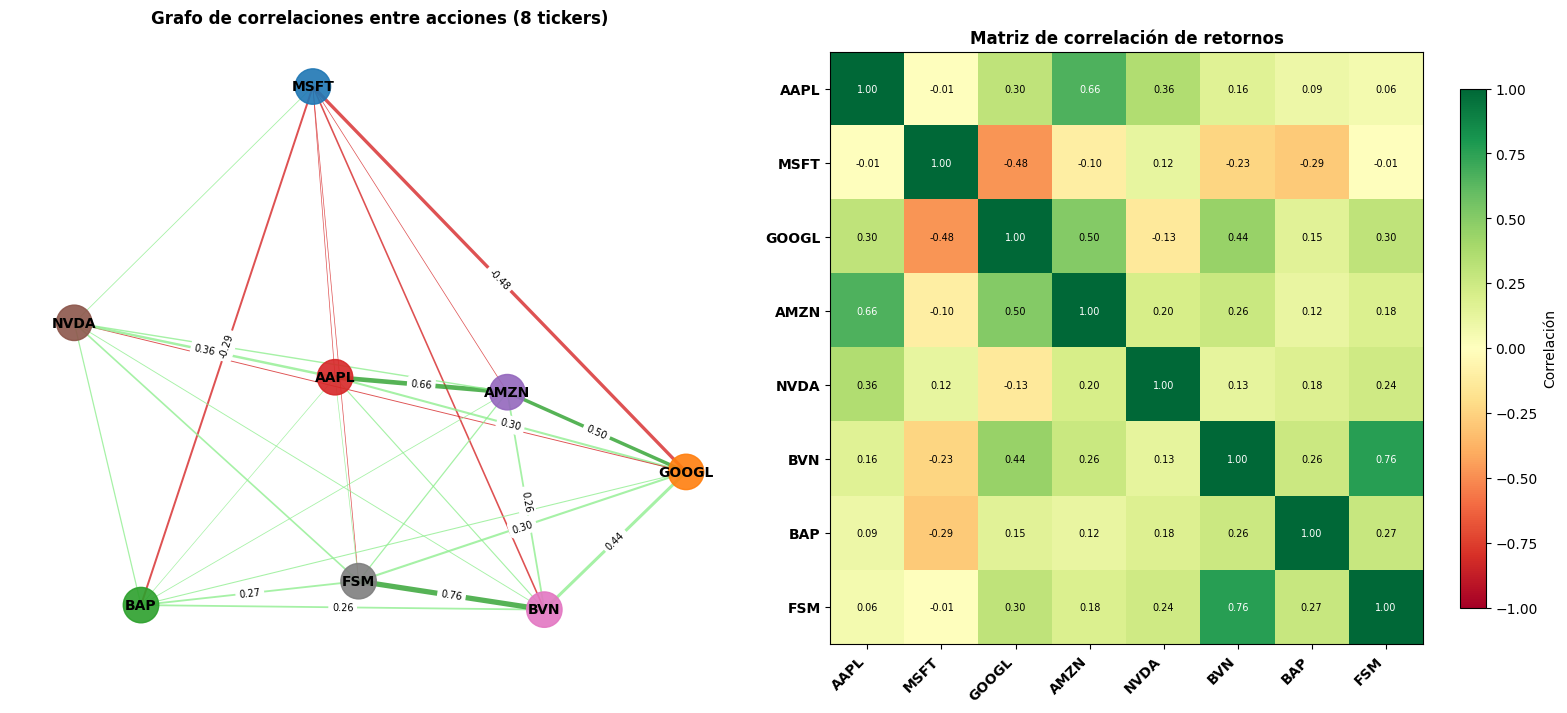

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(16,7))
pos = nx.spring_layout(G, seed=42, k=1.25)
edge_colors = ['#2ca02c' if d['weight'] > 0.5 else '#90EE90' if d['weight'] > 0 else '#d62728' for _,_,d in G.edges(data=True)]
edge_widths = [max(0.5, abs(d['weight'])*5) for _,_,d in G.edges(data=True)]
node_sizes = [max(650, G.nodes[n]['volatilidad']*45) for n in G.nodes()]
node_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f']
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color=edge_colors, width=edge_widths, alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=10, font_weight='bold')
edge_labels = {(u,v): f'{d["weight"]:.2f}' for u,v,d in G.edges(data=True) if abs(d['weight']) >= 0.25}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[0], font_size=7)
axes[0].set_title('Grafo de correlaciones entre acciones (8 tickers)', fontweight='bold')
axes[0].axis('off')
im = axes[1].imshow(corr_matrix.loc[tickers,tickers].values, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(tickers))); axes[1].set_yticks(range(len(tickers)))
axes[1].set_xticklabels(tickers, rotation=45, ha='right', fontweight='bold'); axes[1].set_yticklabels(tickers, fontweight='bold')
for i in range(len(tickers)):
    for j in range(len(tickers)):
        val = corr_matrix.loc[tickers[i], tickers[j]]
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color='white' if abs(val)>0.6 else 'black')
axes[1].set_title('Matriz de correlación de retornos', fontweight='bold')
plt.colorbar(im, ax=axes[1], shrink=0.82, label='Correlación')
plt.tight_layout()
plt.savefig('nosql_grafos_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Dashboard NoSQL comparativo

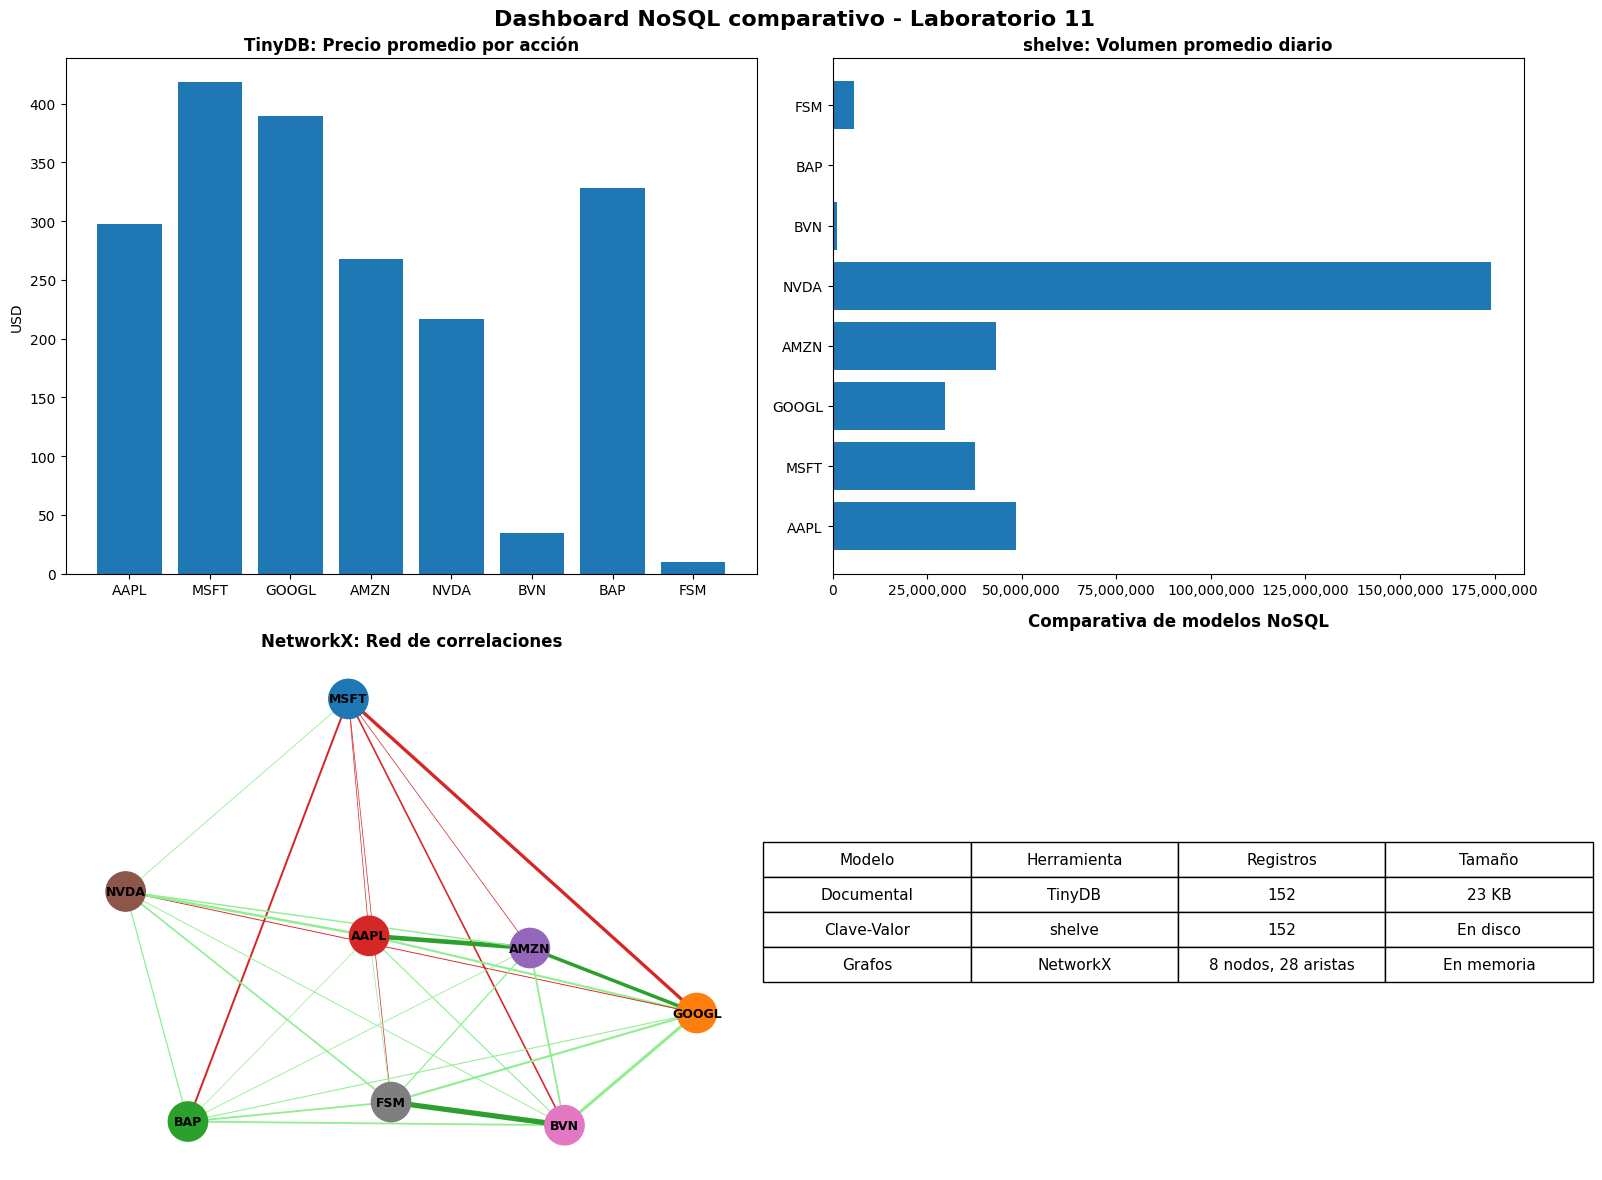

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(16,12))
ax1, ax2, ax3, ax4 = axes.ravel()
res_ord = resumen.set_index('ticker').loc[tickers].reset_index()
ax1.bar(res_ord['ticker'], res_ord['precio_promedio'])
ax1.set_title('TinyDB: Precio promedio por acción', fontweight='bold')
ax1.set_ylabel('USD')
avgvol = pdf_precios.groupby('ticker')['volumen'].mean().reindex(tickers)
ax2.barh(avgvol.index, avgvol.values)
ax2.set_title('shelve: Volumen promedio diario', fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
nx.draw_networkx(G, pos, ax=ax3, node_size=800, node_color=node_colors, edge_color=edge_colors, width=edge_widths, font_size=9, font_weight='bold')
ax3.set_title('NetworkX: Red de correlaciones', fontweight='bold'); ax3.axis('off')
ax4.axis('off')
tabla_data = [['Modelo','Herramienta','Registros','Tamaño'], ['Documental','TinyDB',f'{len(tabla_acciones.all()):,}',f'{os.path.getsize(DB_PATH)/1024:.0f} KB'], ['Clave-Valor','shelve',f'{len(pdf_precios):,}','En disco'], ['Grafos','NetworkX',f'{G.number_of_nodes()} nodos, {G.number_of_edges()} aristas','En memoria']]
table = ax4.table(cellText=tabla_data[1:], colLabels=tabla_data[0], cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 1.7)
ax4.set_title('Comparativa de modelos NoSQL', fontweight='bold', pad=20)
plt.suptitle('Dashboard NoSQL comparativo - Laboratorio 11', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_nosql_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ejercicio A - Análisis del cambio en el grafo

Al agregar `BVN`, `BAP` y `FSM`, el grafo cambia de una red compuesta solo por tecnológicas a una red mixta. La estructura conserva conexiones fuertes dentro de tecnología, pero aparecen nuevas relaciones vinculadas al mercado peruano/minero: `BVN-FSM` funciona como relación sectorial de minería/metales, mientras `BAP` se conecta como nodo financiero con comportamiento distinto al bloque tecnológico.

In [ ]:
top_edges = pd.DataFrame([{'par': f'{u}-{v}', 'correlacion': d['weight'], 'tipo': d['tipo']} for u,v,d in sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:8]])
centralidad = pd.DataFrame({'ticker': list(G.nodes()), 'grado': pd.Series(nx.degree_centrality(G)).reindex(G.nodes()).values, 'intermediacion': pd.Series(nx.betweenness_centrality(G)).reindex(G.nodes()).values, 'cercania': pd.Series(nx.closeness_centrality(G)).reindex(G.nodes()).values})
display(top_edges)
display(centralidad.sort_values('intermediacion', ascending=False))

,par,correlacion,tipo
0,BVN-FSM,0.7582,positiva
1,AAPL-AMZN,0.6639,positiva
2,GOOGL-AMZN,0.5002,positiva
3,GOOGL-BVN,0.4378,positiva
4,AAPL-NVDA,0.3552,positiva
5,GOOGL-FSM,0.3039,positiva
6,GOOGL-AAPL,0.2997,positiva
7,BAP-FSM,0.2659,positiva


,ticker,grado,intermediacion,cercania
0,MSFT,1.0,0.0,1.0
1,GOOGL,1.0,0.0,1.0
2,BAP,1.0,0.0,1.0
3,AAPL,1.0,0.0,1.0
4,AMZN,1.0,0.0,1.0
5,NVDA,1.0,0.0,1.0
6,BVN,1.0,0.0,1.0
7,FSM,1.0,0.0,1.0


## 8. Ejercicio B - Consulta avanzada TinyDB: 5 mayores caídas porcentuales por acción

In [ ]:
from tinydb import TinyDB
import pandas as pd
import os

# En Colab se usará /content; en ejecución local se usará el directorio actual.
DB_CANDIDATES = ['/content/stocks_nosql.json', 'stocks_nosql.json']
DB_PATH_QUERY = next((p for p in DB_CANDIDATES if os.path.exists(p)), 'stocks_nosql.json')
db = TinyDB(DB_PATH_QUERY)
tabla_acciones = db.table('acciones')

# Convertir documentos TinyDB a DataFrame para calcular la variación intradía.
docs = tabla_acciones.all()
caidas = []
for doc in docs:
    caida_pct = ((doc['cierre'] - doc['apertura']) / doc['apertura']) * 100
    caidas.append({
        'ticker': doc['ticker'],
        'fecha': doc['fecha'],
        'apertura': doc['apertura'],
        'cierre': doc['cierre'],
        'caida_pct': round(caida_pct, 2)
    })

caidas_df = pd.DataFrame(caidas)
top5_caidas = (caidas_df
    .sort_values(['ticker', 'caida_pct'])
    .groupby('ticker')
    .head(5)
    .sort_values(['ticker', 'caida_pct']))

print(top5_caidas.to_string(index=False))


ticker      fecha  apertura  cierre  caida_pct
  AAPL 2026-05-18    300.24  297.84      -0.80
  AAPL 2026-05-07    289.27  287.44      -0.63
  AAPL 2026-05-14    299.82  298.21      -0.54
  AAPL 2026-05-26    309.56  308.33      -0.40
  AAPL 2026-05-29    311.78  312.06       0.09
  AMZN 2026-04-30    273.17  265.06      -2.97
  AMZN 2026-05-07    275.02  271.17      -1.40
  AMZN 2026-05-19    262.04  259.34      -1.03
  AMZN 2026-05-26    267.94  265.29      -0.99
  AMZN 2026-05-22    268.66  266.32      -0.87
   BAP 2026-05-22    344.48  334.30      -2.96
   BAP 2026-05-11    330.59  322.42      -2.47
   BAP 2026-05-13    323.33  317.68      -1.75
   BAP 2026-05-15    321.90  316.31      -1.74
   BAP 2026-05-28    345.77  341.50      -1.23
   BVN 2026-05-15     35.60   34.29      -3.68
   BVN 2026-05-07     34.80   33.93      -2.50
   BVN 2026-05-14     38.09   37.15      -2.47
   BVN 2026-04-29     30.66   30.02      -2.09
   BVN 2026-05-18     34.50   34.01      -1.42
   FSM 2026-0

## 9. Diagramas Mermaid solicitados

### Diagrama de secuencia UML
```mermaid
sequenceDiagram
actor Usuario
participant NB as Notebook Colab
participant YF as Yahoo Finance / fuente bursátil
participant PD as pandas
participant SP as PySpark/SparkSQL
participant TDB as TinyDB
participant KV as shelve
participant NX as NetworkX
participant PLT as matplotlib
Usuario->>NB: Ejecuta pipeline del laboratorio
NB->>YF: Descarga OHLCV de 8 tickers
YF-->>NB: Datos bursátiles históricos
NB->>PD: concatena y limpia DataFrames
PD->>SP: crea Spark DataFrame y vista SQL
SP->>TDB: inserta documentos JSON
SP->>KV: guarda pares clave-valor
SP->>NX: calcula retornos y matriz de correlación
NX->>PLT: grafo + heatmap
TDB-->>NB: consulta top 5 caídas porcentuales
NB-->>Usuario: notebook, bases, gráficos e informe

```

### Diagrama de evolución de la data
```mermaid
flowchart TD
Inicio([Inicio]) --> Yahoo[Yahoo Finance / fuente bursátil]
Yahoo --> DF[DF por ticker]
DF --> all_data[all_data: lista de DataFrames]
all_data --> pdf_raw[pdf_raw: DataFrame consolidado]
pdf_raw --> sdf_clean[sdf_clean: Spark DataFrame limpio]
sdf_clean --> precios[precios_acciones: vista SQL Spark]
precios --> resumen[pdf_resumen: estadística por ticker]
sdf_clean --> TinyDB[stocks_nosql.json / TinyDB]
sdf_clean --> Shelve[stocks_keyvalue.db / shelve]
sdf_clean --> Retornos[retornos diarios]
Retornos --> Corr[corr_matrix]
Corr --> G[NetworkX G]
G --> Grafico[nosql_grafos_correlaciones.png]
TinyDB --> Caidas[Consulta TinyDB: top 5 caídas]
TinyDB --> Dashboard[dashboard_nosql_comparativo.png]
Shelve --> Dashboard
G --> Dashboard

```

## 10. Conclusiones

1. TinyDB permitió almacenar los registros OHLCV como documentos JSON y consultar variaciones intradía sin depender de un servidor externo.
2. shelve representó el enfoque clave-valor con claves compuestas `TICKER:FECHA`, útil para búsquedas directas por activo y fecha.
3. NetworkX permitió representar relaciones financieras como un grafo de correlaciones; al agregar BVN, BAP y FSM, el análisis dejó de ser solo tecnológico e incorporó relaciones sectoriales de minería y finanzas.